# EDA 15.1: Revenue = Orders x AOV Decomposition

This notebook decomposes Revenue into order count and Average Order Value (AOV), then examines whether Revenue changes, spikes, and seasonal peaks are driven more by order volume or order value.

## 1. Setup and File Discovery

Locate required and optional CSV files under the current working directory. Missing files generate warnings and the notebook continues where possible.

In [ ]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 240)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['orders.csv', 'order_items.csv', 'payments.csv', 'sales.csv']
REQUIRED = {'orders.csv', 'order_items.csv'}

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())
def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in REQUIRED, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in REQUIRED:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,orders.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
1,order_items.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
2,payments.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\pa...
3,sales.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...


## 2. Load Orders, Order Items, and Optional Files

Load all available inputs safely with pandas and display schema summaries.

In [2]:
def load_csv_safe(path):
    if path is None:
        return None
    try:
        return pd.read_csv(path, low_memory=False)
    except Exception as exc:
        warnings.warn(f'Failed to load {path}: {exc}')
        return None

data = {name.replace('.csv', ''): load_csv_safe(path) for name, path in selected_paths.items()}
orders = data.get('orders')
order_items = data.get('order_items')
payments = data.get('payments')
sales = data.get('sales')

schema_rows = []
for name, df in data.items():
    schema_rows.append({
        'dataset': name,
        'loaded': df is not None,
        'rows': None if df is None else len(df),
        'columns': None if df is None else ', '.join(map(str, df.columns[:20]))
    })
display(pd.DataFrame(schema_rows))

,dataset,loaded,rows,columns
0,orders,True,646945,"order_id, order_date, customer_id, zip, order_..."
1,order_items,True,714669,"order_id, product_id, quantity, unit_price, di..."
2,payments,True,646945,"order_id, payment_method, payment_value, insta..."
3,sales,True,3833,"Date, Revenue, COGS"


## 3. Identify Key, Date, Revenue, Payment, and Status Columns

Use tolerant matching for likely naming variations. Revenue is reconstructed from `order_items` first, with `payments` used as an optional cross-check.

In [3]:
def normalized_map(columns):
    return {normalize_name(c): c for c in columns}

def find_column(columns, candidates, contains=False):
    nmap = normalized_map(columns)
    normalized_candidates = [normalize_name(c) for c in candidates]
    for cand in normalized_candidates:
        if cand in nmap:
            return nmap[cand]
    if contains:
        for cand in normalized_candidates:
            for ncol, raw in nmap.items():
                if cand in ncol:
                    return raw
    return None

orders_cols = {}
if orders is not None:
    orders_cols = {
        'order_id': find_column(orders.columns, ['order_id']),
        'order_date': find_column(orders.columns, ['order_date', 'date', 'created_at'], contains=True),
        'order_status': find_column(orders.columns, ['order_status', 'status'], contains=True),
        'order_total': find_column(orders.columns, ['order_total', 'revenue', 'sales_amount', 'amount', 'total', 'gmv'], contains=True),
    }

order_item_cols = {}
if order_items is not None:
    order_item_cols = {
        'order_id': find_column(order_items.columns, ['order_id']),
        'product_id': find_column(order_items.columns, ['product_id']),
        'quantity': find_column(order_items.columns, ['quantity', 'qty', 'units'], contains=True),
        'price': find_column(order_items.columns, ['unit_price', 'price', 'selling_price'], contains=True),
        'discount': find_column(order_items.columns, ['discount_amount', 'discount'], contains=True),
        'amount': find_column(order_items.columns, ['revenue', 'item_total', 'line_total', 'sales_amount', 'net_sales'], contains=True),
    }

payment_cols = {}
if payments is not None:
    payment_cols = {
        'order_id': find_column(payments.columns, ['order_id']),
        'payment_amount': find_column(payments.columns, ['payment_value', 'payment_amount', 'amount', 'value'], contains=True),
        'payment_status': find_column(payments.columns, ['payment_status', 'status'], contains=True),
    }

sales_cols = {}
if sales is not None:
    sales_cols = {
        'date': find_column(sales.columns, ['date', 'sales_date', 'order_date'], contains=True),
        'revenue': find_column(sales.columns, ['revenue', 'sales_amount', 'total_revenue'], contains=True),
    }

identified = pd.DataFrame({
    'orders': pd.Series(orders_cols),
    'order_items': pd.Series(order_item_cols),
    'payments': pd.Series(payment_cols),
    'sales': pd.Series(sales_cols),
})
display(identified)

if orders is not None and (orders_cols.get('order_id') is None or orders_cols.get('order_date') is None):
    warnings.warn('Order ID or order date could not be identified reliably. Some decomposition analysis may be skipped.')

,orders,order_items,payments,sales
amount,NaN,None,NaN,NaN
date,NaN,NaN,NaN,Date
discount,NaN,discount_amount,NaN,NaN
order_date,order_date,NaN,NaN,NaN
order_id,order_id,order_id,order_id,NaN
order_status,order_status,NaN,NaN,NaN
order_total,None,NaN,NaN,NaN
payment_amount,NaN,NaN,payment_value,NaN
payment_status,NaN,NaN,None,NaN
price,NaN,unit_price,NaN,NaN


## 4. Build Order-Level Revenue Dataset

Reconstruct order-level Revenue. Item-level reconstruction is the primary source here because `orders.csv` does not expose a direct order total in this dataset.

In [4]:
decomp_warnings = []
order_level = pd.DataFrame()

if orders is not None:
    orders_clean = orders.copy()
    orders_clean['order_id_std'] = orders_clean[orders_cols['order_id']] if orders_cols.get('order_id') else pd.NA
    orders_clean['order_date_std'] = pd.to_datetime(orders_clean[orders_cols['order_date']], errors='coerce') if orders_cols.get('order_date') else pd.NaT
    orders_clean['order_status_std'] = orders_clean[orders_cols['order_status']].astype(str).str.strip().str.lower() if orders_cols.get('order_status') else pd.NA
    orders_clean['order_revenue_raw'] = pd.to_numeric(orders_clean[orders_cols['order_total']], errors='coerce') if orders_cols.get('order_total') else np.nan
else:
    orders_clean = None

if order_items is not None and order_item_cols.get('order_id'):
    oi = order_items.copy()
    oi['order_id_std'] = oi[order_item_cols['order_id']]
    if order_item_cols.get('amount'):
        oi['item_revenue_std'] = pd.to_numeric(oi[order_item_cols['amount']], errors='coerce')
    else:
        qty = pd.to_numeric(oi[order_item_cols['quantity']], errors='coerce') if order_item_cols.get('quantity') else np.nan
        price = pd.to_numeric(oi[order_item_cols['price']], errors='coerce') if order_item_cols.get('price') else np.nan
        discount = pd.to_numeric(oi[order_item_cols['discount']], errors='coerce').fillna(0) if order_item_cols.get('discount') else 0
        oi['item_revenue_std'] = qty * price
    item_order_rev = oi.groupby('order_id_std').agg(
        order_revenue_items=('item_revenue_std', 'sum'),
        item_line_count=('order_id_std', 'size'),
    ).reset_index()
else:
    item_order_rev = pd.DataFrame(columns=['order_id_std', 'order_revenue_items', 'item_line_count'])

if payments is not None and payment_cols.get('order_id') and payment_cols.get('payment_amount'):
    pay = payments.copy()
    pay['order_id_std'] = pay[payment_cols['order_id']]
    pay['payment_amount_std'] = pd.to_numeric(pay[payment_cols['payment_amount']], errors='coerce')
    pay['payment_status_std'] = pay[payment_cols['payment_status']].astype(str).str.strip().str.lower() if payment_cols.get('payment_status') else pd.NA
    pay_order = pay.groupby('order_id_std').agg(
        payment_amount_total=('payment_amount_std', 'sum'),
        payment_row_count=('order_id_std', 'size'),
    ).reset_index()
else:
    pay_order = pd.DataFrame(columns=['order_id_std', 'payment_amount_total', 'payment_row_count'])

if orders_clean is not None:
    order_level = orders_clean.merge(item_order_rev, on='order_id_std', how='left', indicator='item_merge')
    order_level = order_level.merge(pay_order, on='order_id_std', how='left')
    if order_level['order_revenue_raw'].notna().sum() > 0:
        order_level['order_revenue'] = order_level['order_revenue_raw'].fillna(order_level['order_revenue_items'])
        revenue_source = f"orders.{orders_cols['order_total']}"
    else:
        order_level['order_revenue'] = order_level['order_revenue_items']
        revenue_source = 'order_items reconstructed revenue'
    order_level['is_cancelled_like'] = order_level['order_status_std'].astype(str).str.contains('cancel|failed|void', case=False, na=False)
    order_level['is_returned_like'] = order_level['order_status_std'].astype(str).str.contains('return|refund', case=False, na=False)
    order_level['order_count'] = 1

    quality = pd.DataFrame([{
        'revenue_source': revenue_source,
        'number_of_orders': len(order_level),
        'duplicated_order_ids': int(order_level.duplicated(subset=['order_id_std']).sum()),
        'orders_with_missing_revenue': int(order_level['order_revenue'].isna().sum()),
        'zero_or_negative_revenue': int(order_level['order_revenue'].fillna(0).le(0).sum()),
        'cancelled_or_failed_orders': int(order_level['is_cancelled_like'].sum()),
        'returned_orders': int(order_level['is_returned_like'].sum()),
        'order_items_matched_to_orders': int((order_level['item_merge'] == 'both').sum()),
        'payments_matched_to_orders': int(order_level['payment_amount_total'].notna().sum()),
    }])
    display(quality)
    if quality.loc[0, 'orders_with_missing_revenue'] > 0:
        decomp_warnings.append(f"{quality.loc[0, 'orders_with_missing_revenue']} orders have missing revenue")
    if quality.loc[0, 'zero_or_negative_revenue'] > 0:
        decomp_warnings.append(f"{quality.loc[0, 'zero_or_negative_revenue']} orders have zero or negative revenue")

    if 'payment_amount_total' in order_level.columns and order_level['payment_amount_total'].notna().any():
        compare = order_level[['order_revenue', 'payment_amount_total']].dropna()
        if not compare.empty:
            display(pd.DataFrame([{
                'order_vs_payment_corr': compare['order_revenue'].corr(compare['payment_amount_total']),
                'mean_abs_difference': (compare['order_revenue'] - compare['payment_amount_total']).abs().mean(),
                'total_difference': (compare['order_revenue'] - compare['payment_amount_total']).sum(),
            }]))
else:
    warnings.warn('Order-level Revenue dataset could not be built because orders.csv is unavailable.')

,revenue_source,number_of_orders,duplicated_order_ids,orders_with_missing_revenue,zero_or_negative_revenue,cancelled_or_failed_orders,returned_orders,order_items_matched_to_orders,payments_matched_to_orders
0,order_items reconstructed revenue,646945,0,0,0,59462,36142,646945,646945


,order_vs_payment_corr,mean_abs_difference,total_difference
0,0.9947,"1,158.6879","749,607,320.1000"


## 5. Order-Level Data Quality Checks

Summarize duplicate keys, missing dates, missing Revenue, and status flags before the decomposition time series is built.

In [5]:
if not order_level.empty:
    quality_summary = pd.DataFrame([{
        'missing_order_dates': int(order_level['order_date_std'].isna().sum()),
        'missing_revenue': int(order_level['order_revenue'].isna().sum()),
        'zero_or_negative_revenue': int(order_level['order_revenue'].fillna(0).le(0).sum()),
        'cancelled_like_orders': int(order_level['is_cancelled_like'].sum()),
        'returned_like_orders': int(order_level['is_returned_like'].sum()),
    }])
    display(quality_summary)

,missing_order_dates,missing_revenue,zero_or_negative_revenue,cancelled_like_orders,returned_like_orders
0,0,0,0,59462,36142


## 6. Prepare Daily Revenue = Orders x AOV Decomposition

Aggregate to day level and compute `Revenue`, `order_count`, and `AOV = Revenue / order_count`.

In [6]:
daily = pd.DataFrame()
monthly = pd.DataFrame()
yearly = pd.DataFrame()

if not order_level.empty and order_level['order_date_std'].notna().any():
    valid = order_level.dropna(subset=['order_date_std']).copy()
    valid['date'] = valid['order_date_std'].dt.floor('D')
    daily = valid.groupby('date').agg(
        Revenue=('order_revenue', 'sum'),
        order_count=('order_count', 'sum'),
    ).reset_index()
    daily['AOV'] = np.where(daily['order_count'] > 0, daily['Revenue'] / daily['order_count'], np.nan)

    full_dates = pd.date_range(daily['date'].min(), daily['date'].max(), freq='D')
    daily = pd.DataFrame({'date': full_dates}).merge(daily, on='date', how='left')
    daily['Revenue'] = daily['Revenue'].fillna(0)
    daily['order_count'] = daily['order_count'].fillna(0)
    daily['AOV'] = np.where(daily['order_count'] > 0, daily['Revenue'] / daily['order_count'], np.nan)
    daily['month'] = daily['date'].dt.to_period('M').dt.to_timestamp()
    daily['year'] = daily['date'].dt.year
    daily['month_of_year'] = daily['date'].dt.month

    monthly = daily.groupby('month').agg(
        Revenue=('Revenue', 'sum'),
        order_count=('order_count', 'sum'),
    ).reset_index()
    monthly['AOV'] = np.where(monthly['order_count'] > 0, monthly['Revenue'] / monthly['order_count'], np.nan)

    yearly = daily.groupby('year').agg(
        Revenue=('Revenue', 'sum'),
        order_count=('order_count', 'sum'),
    ).reset_index()
    yearly['AOV'] = np.where(yearly['order_count'] > 0, yearly['Revenue'] / yearly['order_count'], np.nan)

    summary = pd.DataFrame([{
        'date_range_start': daily['date'].min(),
        'date_range_end': daily['date'].max(),
        'number_of_days': len(daily),
        'missing_dates_after_reindex': 0,
        'total_revenue': daily['Revenue'].sum(),
        'total_orders': daily['order_count'].sum(),
        'overall_AOV': daily['Revenue'].sum() / daily['order_count'].sum() if daily['order_count'].sum() > 0 else np.nan,
        'avg_daily_revenue': daily['Revenue'].mean(),
        'avg_daily_order_count': daily['order_count'].mean(),
        'avg_daily_AOV': daily['AOV'].mean(),
    }])
    display(summary)
    display(daily.head(10))

,date_range_start,date_range_end,number_of_days,missing_dates_after_reindex,total_revenue,total_orders,overall_AOV,avg_daily_revenue,avg_daily_order_count,avg_daily_AOV
0,2012-07-04,2022-12-31,3833,0,"16,430,476,585.5300",646945,"25,397.0223","4,286,584.0296",168.7829,"26,754.0739"


,date,Revenue,order_count,AOV,month,year,month_of_year
0,2012-07-04,"5,123,547.9400",162,"31,626.8391",2012-07-01,2012,7
1,2012-07-05,"2,751,773.4500",97,"28,368.7985",2012-07-01,2012,7
2,2012-07-06,"3,054,029.4200",93,"32,839.0260",2012-07-01,2012,7
3,2012-07-07,"2,667,930.9400",73,"36,546.9992",2012-07-01,2012,7
4,2012-07-08,"2,360,851.9000",88,"26,827.8625",2012-07-01,2012,7
5,2012-07-09,"3,548,386.4600",137,"25,900.6311",2012-07-01,2012,7
6,2012-07-10,"5,234,938.6200",183,"28,606.2220",2012-07-01,2012,7
7,2012-07-11,"5,582,884.7800",221,"25,261.9221",2012-07-01,2012,7
8,2012-07-12,"5,734,632.0200",246,"23,311.5123",2012-07-01,2012,7
9,2012-07-13,"5,309,511.7100",201,"26,415.4811",2012-07-01,2012,7


## 7. Revenue, Order Count, and AOV Over Time

Plot Revenue, order count, and AOV separately, then compare indexed movement from a common base of 100.

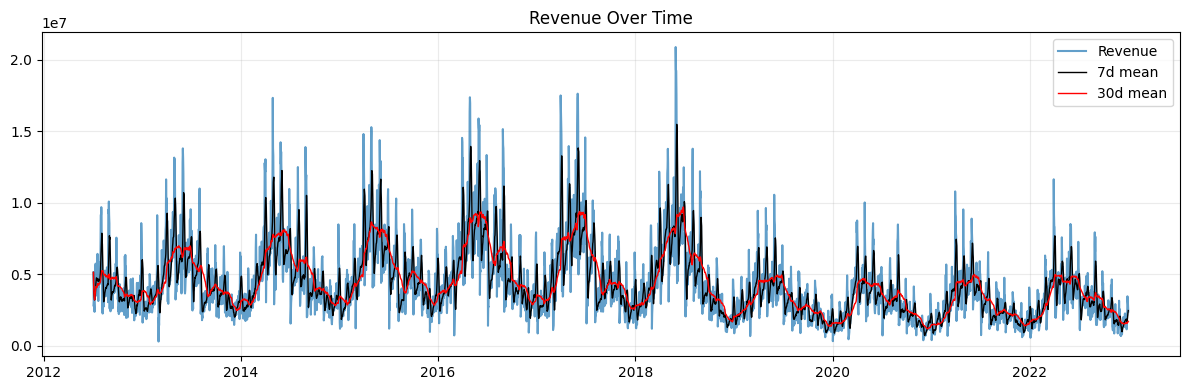

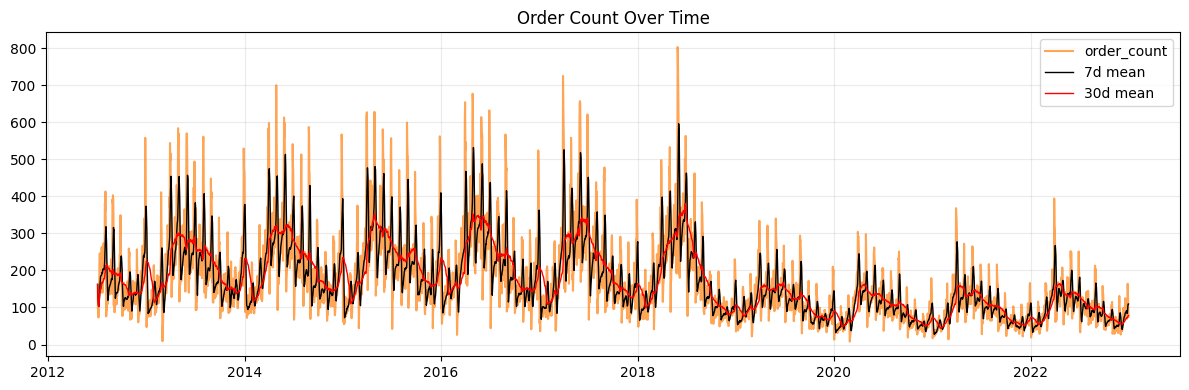

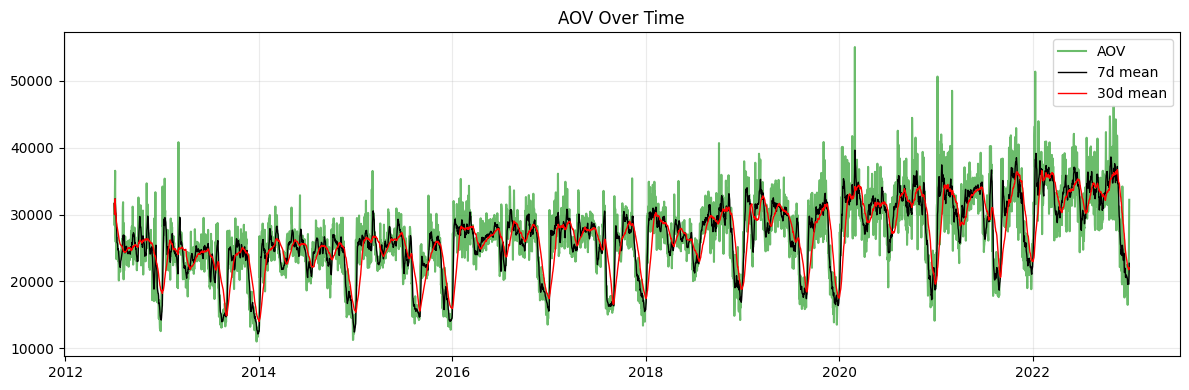

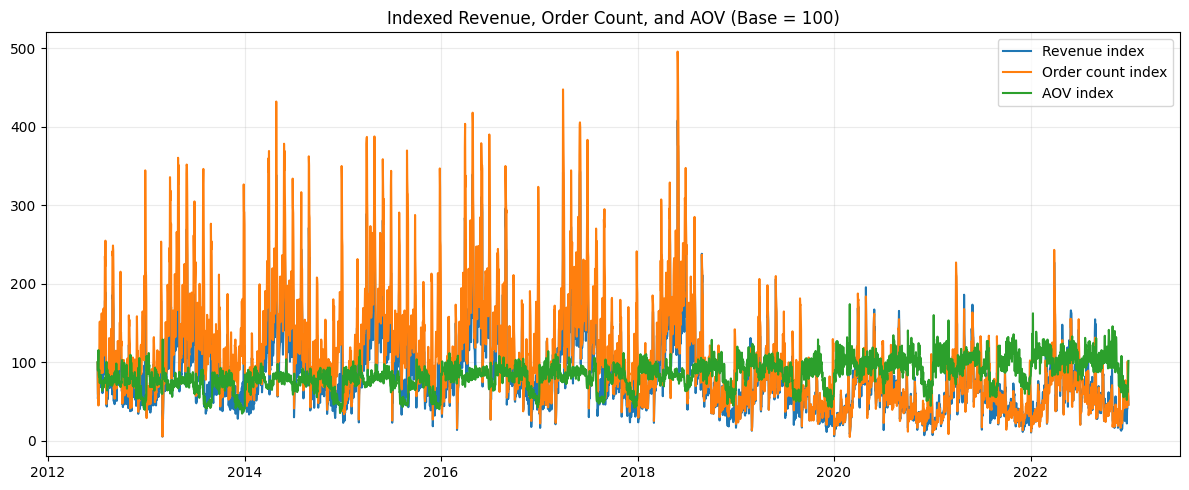

In [7]:
if not daily.empty:
    for col, title, color in [('Revenue', 'Revenue Over Time', 'tab:blue'),
                              ('order_count', 'Order Count Over Time', 'tab:orange'),
                              ('AOV', 'AOV Over Time', 'tab:green')]:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(daily['date'], daily[col], color=color, alpha=0.7, label=col)
        ax.plot(daily['date'], daily[col].rolling(7, min_periods=1).mean(), color='black', linewidth=1, label='7d mean')
        ax.plot(daily['date'], daily[col].rolling(30, min_periods=1).mean(), color='red', linewidth=1, label='30d mean')
        ax.set_title(title)
        ax.legend()
        plt.tight_layout()
        plt.show()

    indexed = daily[['date', 'Revenue', 'order_count', 'AOV']].copy()
    for col in ['Revenue', 'order_count', 'AOV']:
        first_valid = indexed[col].replace(0, np.nan).dropna()
        if len(first_valid):
            base = first_valid.iloc[0]
            indexed[f'{col}_index'] = indexed[col] / base * 100
        else:
            indexed[f'{col}_index'] = np.nan

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(indexed['date'], indexed['Revenue_index'], label='Revenue index')
    ax.plot(indexed['date'], indexed['order_count_index'], label='Order count index')
    ax.plot(indexed['date'], indexed['AOV_index'], label='AOV index')
    ax.set_title('Indexed Revenue, Order Count, and AOV (Base = 100)')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 8. Correlation and Driver Comparison

Compare whether Revenue aligns more strongly with order count or AOV overall, by year, by month-of-year, and during high-Revenue periods.

In [8]:
driver_tables = []

if not daily.empty:
    driver_tables.append({
        'period': 'overall',
        'revenue_vs_order_count': daily['Revenue'].corr(daily['order_count']),
        'revenue_vs_AOV': daily['Revenue'].corr(daily['AOV']),
        'order_count_vs_AOV': daily['order_count'].corr(daily['AOV']),
    })

    for year, grp in daily.groupby('year'):
        driver_tables.append({
            'period': f'year_{year}',
            'revenue_vs_order_count': grp['Revenue'].corr(grp['order_count']),
            'revenue_vs_AOV': grp['Revenue'].corr(grp['AOV']),
            'order_count_vs_AOV': grp['order_count'].corr(grp['AOV']),
        })

    for m, grp in daily.groupby('month_of_year'):
        driver_tables.append({
            'period': f'month_{m:02d}',
            'revenue_vs_order_count': grp['Revenue'].corr(grp['order_count']),
            'revenue_vs_AOV': grp['Revenue'].corr(grp['AOV']),
            'order_count_vs_AOV': grp['order_count'].corr(grp['AOV']),
        })

    high_rev = daily[daily['Revenue'] >= daily['Revenue'].quantile(0.90)]
    if not high_rev.empty:
        driver_tables.append({
            'period': 'high_revenue_days',
            'revenue_vs_order_count': high_rev['Revenue'].corr(high_rev['order_count']),
            'revenue_vs_AOV': high_rev['Revenue'].corr(high_rev['AOV']),
            'order_count_vs_AOV': high_rev['order_count'].corr(high_rev['AOV']),
        })

    driver_df = pd.DataFrame(driver_tables)
    driver_df['dominant_driver'] = np.where(
        driver_df['revenue_vs_order_count'].abs() > driver_df['revenue_vs_AOV'].abs(),
        'order_count',
        'AOV'
    )
    display(driver_df)
else:
    driver_df = pd.DataFrame()

,period,revenue_vs_order_count,revenue_vs_AOV,order_count_vs_AOV,dominant_driver
0,overall,0.9359,-0.0730,-0.3578,order_count
1,year_2012,0.8949,-0.0895,-0.4742,order_count
2,year_2013,0.9116,0.0524,-0.3146,order_count
3,year_2014,0.9370,0.1137,-0.2060,order_count
4,year_2015,0.9076,0.1545,-0.2274,order_count
5,year_2016,0.9560,0.0838,-0.1764,order_count
6,year_2017,0.9446,0.2041,-0.0915,order_count
7,year_2018,0.9776,0.0385,-0.1383,order_count
8,year_2019,0.9165,0.2916,-0.0683,order_count
9,year_2020,0.9631,0.1735,-0.0581,order_count


## 9. Contribution Decomposition Over Time

At monthly level, decompose Revenue change into order-count effect, AOV effect, and interaction effect.

,month,Revenue_change,order_count_effect,AOV_effect,interaction_effect,dominant_driver
0,2012-07-01,NaN,NaN,NaN,NaN,order_count
1,2012-08-01,"28,682,466.8000","27,909,118.6979","637,016.4700","136,331.6321",order_count
2,2012-09-01,"-29,782,106.4900","-29,901,945.2769","147,576.9081","-27,738.1212",order_count
3,2012-10-01,"-19,121,439.3700","-23,140,996.9320","4,895,699.1636","-876,141.6016",order_count
4,2012-11-01,"-11,999,399.2100","-3,677,142.1952","-8,609,577.8147","287,320.7999",AOV
5,2012-12-01,"16,136,315.4500","60,258,223.6842","-27,341,852.7687","-16,780,055.4655",order_count
6,2013-01-01,"-23,013,933.6600","-51,636,738.7303","52,200,499.0695","-23,577,693.9992",AOV
7,2013-02-01,"18,474,460.9100","24,814,036.1042","-4,984,883.7345","-1,354,691.4596",order_count
8,2013-03-01,"42,051,519.3300","45,434,815.0797","-2,392,950.1501","-990,345.5996",order_count
9,2013-04-01,"47,092,274.8200","52,623,726.4347","-4,107,760.4396","-1,423,691.1751",order_count


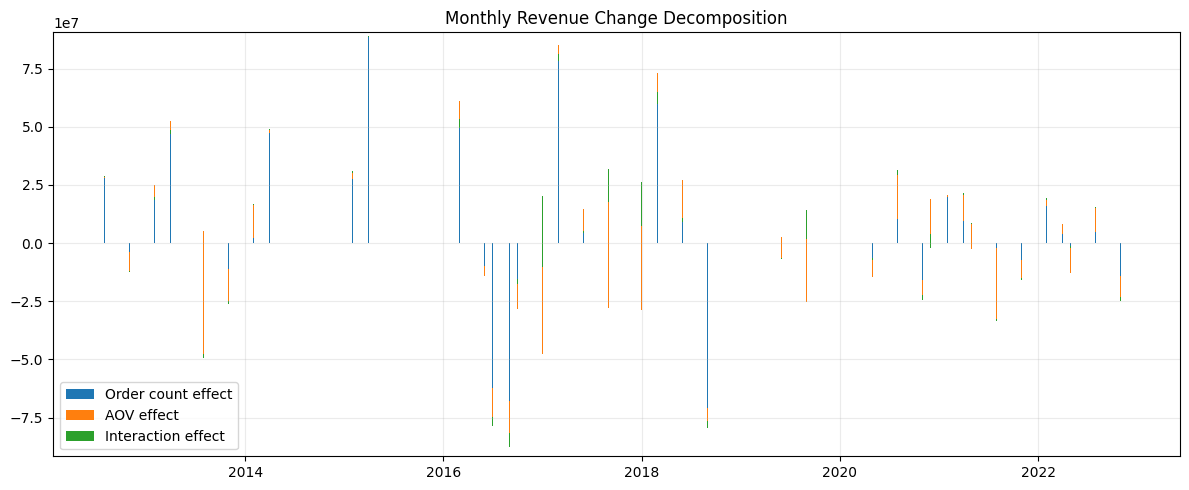

In [9]:
monthly_decomp = pd.DataFrame()

if not monthly.empty:
    monthly_decomp = monthly.copy()
    monthly_decomp['prev_Revenue'] = monthly_decomp['Revenue'].shift(1)
    monthly_decomp['prev_order_count'] = monthly_decomp['order_count'].shift(1)
    monthly_decomp['prev_AOV'] = monthly_decomp['AOV'].shift(1)
    monthly_decomp['Revenue_change'] = monthly_decomp['Revenue'] - monthly_decomp['prev_Revenue']
    monthly_decomp['order_count_effect'] = (monthly_decomp['order_count'] - monthly_decomp['prev_order_count']) * monthly_decomp['prev_AOV']
    monthly_decomp['AOV_effect'] = monthly_decomp['prev_order_count'] * (monthly_decomp['AOV'] - monthly_decomp['prev_AOV'])
    monthly_decomp['interaction_effect'] = (monthly_decomp['order_count'] - monthly_decomp['prev_order_count']) * (monthly_decomp['AOV'] - monthly_decomp['prev_AOV'])

    def dominant_driver(row):
        effects = {
            'order_count': abs(row['order_count_effect']) if pd.notna(row['order_count_effect']) else -1,
            'AOV': abs(row['AOV_effect']) if pd.notna(row['AOV_effect']) else -1,
            'interaction': abs(row['interaction_effect']) if pd.notna(row['interaction_effect']) else -1,
        }
        return max(effects, key=effects.get)

    monthly_decomp['dominant_driver'] = monthly_decomp.apply(dominant_driver, axis=1)
    display(monthly_decomp[['month', 'Revenue_change', 'order_count_effect', 'AOV_effect', 'interaction_effect', 'dominant_driver']].head(18))

    plot_df = monthly_decomp.dropna(subset=['Revenue_change']).copy()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(plot_df['month'], plot_df['order_count_effect'], label='Order count effect')
    ax.bar(plot_df['month'], plot_df['AOV_effect'], bottom=plot_df['order_count_effect'], label='AOV effect')
    ax.bar(plot_df['month'], plot_df['interaction_effect'], bottom=plot_df['order_count_effect'] + plot_df['AOV_effect'], label='Interaction effect')
    ax.set_title('Monthly Revenue Change Decomposition')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 10. Revenue Spike Decomposition

Identify Revenue spike periods and classify whether they are more order-count-driven, AOV-driven, both, or mixed.

,date,Revenue,order_count,AOV,Revenue_percentile,order_count_percentile,AOV_percentile,driver_classification
2156,2018-05-30,"20,905,271.3500",803,"26,033.9618",1.0000,1.0000,0.5156,order_count_driven
2157,2018-05-31,"19,289,944.1200",782,"24,667.4477",0.9948,0.9948,0.3594,order_count_driven
2158,2018-06-01,"19,245,165.7800",725,"26,545.0562",0.9896,0.9870,0.5938,order_count_driven
1793,2017-06-01,"17,639,270.8800",657,"26,848.2053",0.9844,0.9688,0.6667,order_count_driven
2159,2018-06-02,"17,529,108.3400",646,"27,134.8426",0.9792,0.9375,0.7135,order_count_driven
1794,2017-06-02,"17,528,852.8800",647,"27,092.5083",0.9740,0.9427,0.6979,order_count_driven
1730,2017-03-30,"17,516,038.8200",725,"24,160.0535",0.9688,0.9870,0.3021,order_count_driven
1394,2016-04-28,"17,388,183.1900",677,"25,684.1701",0.9635,0.9740,0.4531,order_count_driven
664,2014-04-29,"17,347,427.2700",700,"24,782.0390",0.9583,0.9792,0.3750,order_count_driven
1792,2017-05-31,"17,314,841.8600",652,"26,556.5059",0.9531,0.9479,0.5990,order_count_driven


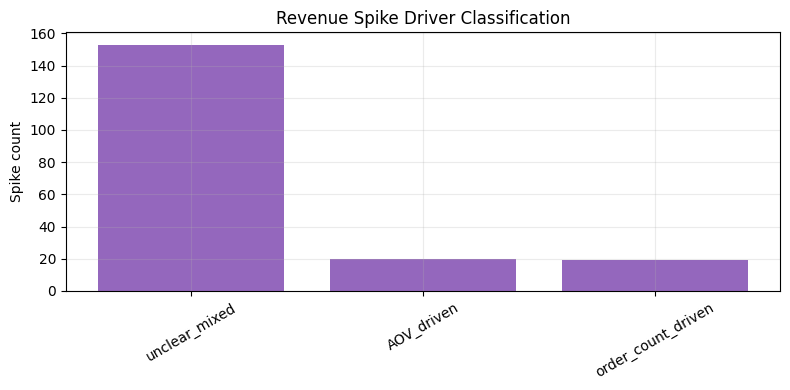

In [10]:
spike_df = pd.DataFrame()

if not daily.empty:
    rev_threshold = daily['Revenue'].quantile(0.95)
    spike_df = daily[daily['Revenue'] >= rev_threshold].copy()
    spike_df['Revenue_percentile'] = spike_df['Revenue'].rank(pct=True)
    spike_df['order_count_percentile'] = spike_df['order_count'].rank(pct=True)
    spike_df['AOV_percentile'] = spike_df['AOV'].rank(pct=True)

    def classify_spike(row):
        high_orders = row['order_count_percentile'] >= 0.90
        high_aov = row['AOV_percentile'] >= 0.90
        if high_orders and high_aov:
            return 'both'
        if high_orders:
            return 'order_count_driven'
        if high_aov:
            return 'AOV_driven'
        return 'unclear_mixed'

    spike_df['driver_classification'] = spike_df.apply(classify_spike, axis=1)
    display(spike_df[['date', 'Revenue', 'order_count', 'AOV', 'Revenue_percentile', 'order_count_percentile', 'AOV_percentile', 'driver_classification']].sort_values('Revenue', ascending=False).head(20))

    spike_counts = spike_df['driver_classification'].value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(spike_counts.index.astype(str), spike_counts.values, color='tab:purple')
    ax.set_title('Revenue Spike Driver Classification')
    ax.set_ylabel('Spike count')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

## 11. Peak Season Decomposition

Identify peak months and assess whether peak seasons are driven by many orders, high AOV, or both.

In [11]:
seasonal_table = pd.DataFrame()

if not monthly.empty:
    seasonal = monthly.copy()
    seasonal['month_of_year'] = seasonal['month'].dt.month
    seasonal_avg = seasonal.groupby('month_of_year').agg(
        Revenue=('Revenue', 'mean'),
        order_count=('order_count', 'mean'),
        AOV=('AOV', 'mean'),
    ).reset_index()
    seasonal_avg['Revenue_rank'] = seasonal_avg['Revenue'].rank(ascending=False, method='dense')
    seasonal_avg['order_count_rank'] = seasonal_avg['order_count'].rank(ascending=False, method='dense')
    seasonal_avg['AOV_rank'] = seasonal_avg['AOV'].rank(ascending=False, method='dense')

    def classify_peak(row):
        high_orders = row['order_count_rank'] <= 3
        high_aov = row['AOV_rank'] <= 3
        if high_orders and high_aov:
            return 'both'
        if high_orders:
            return 'high_order_volume'
        if high_aov:
            return 'high_AOV'
        return 'mixed'

    seasonal_avg['peak_driver'] = seasonal_avg.apply(classify_peak, axis=1)
    seasonal_table = seasonal_avg.sort_values('Revenue_rank')
    display(seasonal_table)

,month_of_year,Revenue,order_count,AOV,Revenue_rank,order_count_rank,AOV_rank,peak_driver
4,5,"203,837,906.8340","7,394.3000","28,615.3244",1.0000,2.0000,3.0000,both
3,4,"195,988,556.4630","7,433.5000","27,257.8186",2.0000,1.0000,6.0000,high_order_volume
5,6,"192,813,259.5680","7,227.0000","27,705.8419",3.0000,3.0000,5.0000,high_order_volume
2,3,"152,773,749.6680","5,744.0000","27,250.1367",4.0000,5.0000,7.0000,mixed
6,7,"143,182,618.9691","5,706.9091","25,869.3413",5.0000,6.0000,9.0000,mixed
7,8,"137,676,998.1900","5,982.8182","23,882.0634",6.0000,4.0000,11.0000,mixed
8,9,"113,934,768.0473","4,459.4545","26,645.2239",7.0000,8.0000,8.0000,mixed
9,10,"102,384,481.7964","3,627.5455","29,505.2621",8.0000,9.0000,1.0000,high_AOV
1,2,"98,158,581.9440","3,503.1000","29,171.5694",9.0000,10.0000,2.0000,high_AOV
0,1,"80,325,792.7410","2,945.0000","28,509.5513",10.0000,12.0000,4.0000,mixed


## 12. Scatter Analysis: Order Count vs AOV

Use daily order count and AOV to identify high-volume/high-value and low-volume/low-value periods.

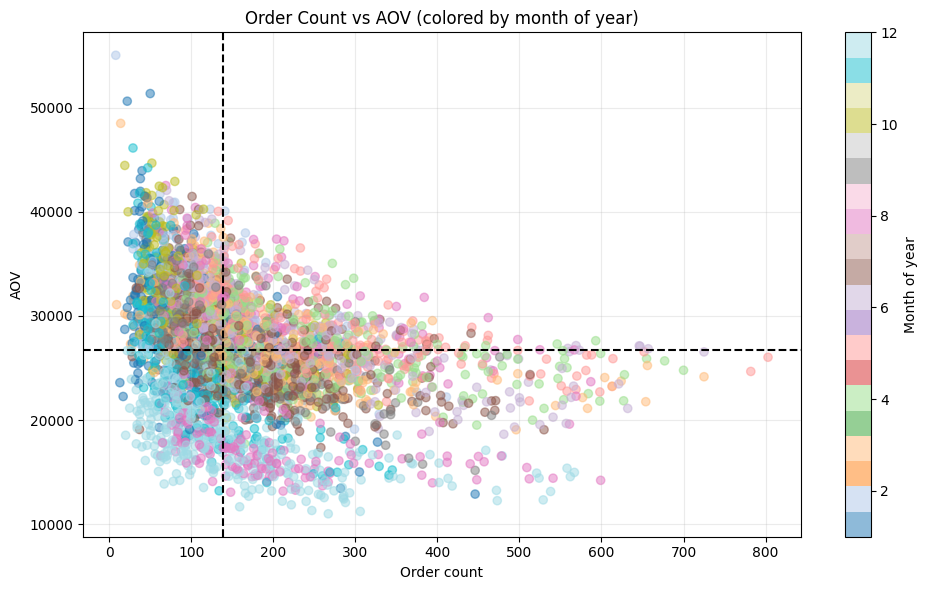

,quadrant,day_count,avg_revenue,avg_order_count,avg_AOV
0,high_orders_high_AOV,650,"6,471,743.2414",221.3600,"29,535.0154"
1,high_orders_low_AOV,1276,"5,793,505.4750",260.7312,"22,241.5721"
2,low_orders_high_AOV,1267,"2,724,159.2471",85.8469,"32,096.7677"
3,low_orders_low_AOV,640,"2,155,969.8850",96.2500,"22,349.6166"


In [12]:
quadrant_table = pd.DataFrame()

if not daily.empty:
    med_orders = daily['order_count'].median()
    med_aov = daily['AOV'].median()
    scatter_df = daily.dropna(subset=['AOV']).copy()
    scatter_df['quadrant'] = np.select(
        [
            (scatter_df['order_count'] >= med_orders) & (scatter_df['AOV'] >= med_aov),
            (scatter_df['order_count'] >= med_orders) & (scatter_df['AOV'] < med_aov),
            (scatter_df['order_count'] < med_orders) & (scatter_df['AOV'] >= med_aov),
        ],
        ['high_orders_high_AOV', 'high_orders_low_AOV', 'low_orders_high_AOV'],
        default='low_orders_low_AOV'
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    sc = ax.scatter(scatter_df['order_count'], scatter_df['AOV'], c=scatter_df['month_of_year'], cmap='tab20', alpha=0.5)
    ax.axvline(med_orders, color='black', linestyle='--')
    ax.axhline(med_aov, color='black', linestyle='--')
    ax.set_title('Order Count vs AOV (colored by month of year)')
    ax.set_xlabel('Order count')
    ax.set_ylabel('AOV')
    plt.colorbar(sc, ax=ax, label='Month of year')
    plt.tight_layout()
    plt.show()

    quadrant_table = scatter_df.groupby('quadrant').agg(
        day_count=('date', 'size'),
        avg_revenue=('Revenue', 'mean'),
        avg_order_count=('order_count', 'mean'),
        avg_AOV=('AOV', 'mean'),
    ).reset_index().sort_values('avg_revenue', ascending=False)
    display(quadrant_table)

## 13. Monthly and Yearly Decomposition

Display monthly and yearly aggregates, then inspect long-term trend drivers.

,month,Revenue,order_count,AOV
0,2012-07-01,"130,406,773.5100",5294,"24,632.9380"
1,2012-08-01,"159,089,240.3100",6427,"24,753.2660"
2,2012-09-01,"129,307,133.8200",5219,"24,776.2280"
3,2012-10-01,"110,185,694.4500",4285,"25,714.2811"
4,2012-11-01,"98,186,295.2400",4142,"23,705.0447"
5,2012-12-01,"114,322,610.6900",6684,"17,103.9214"
6,2013-01-01,"91,308,677.0300",3665,"24,913.6909"
7,2013-02-01,"109,783,137.9400",4661,"23,553.5589"
8,2013-03-01,"151,834,657.2700",6590,"23,040.1604"
9,2013-04-01,"198,926,932.0900",8874,"22,416.8280"


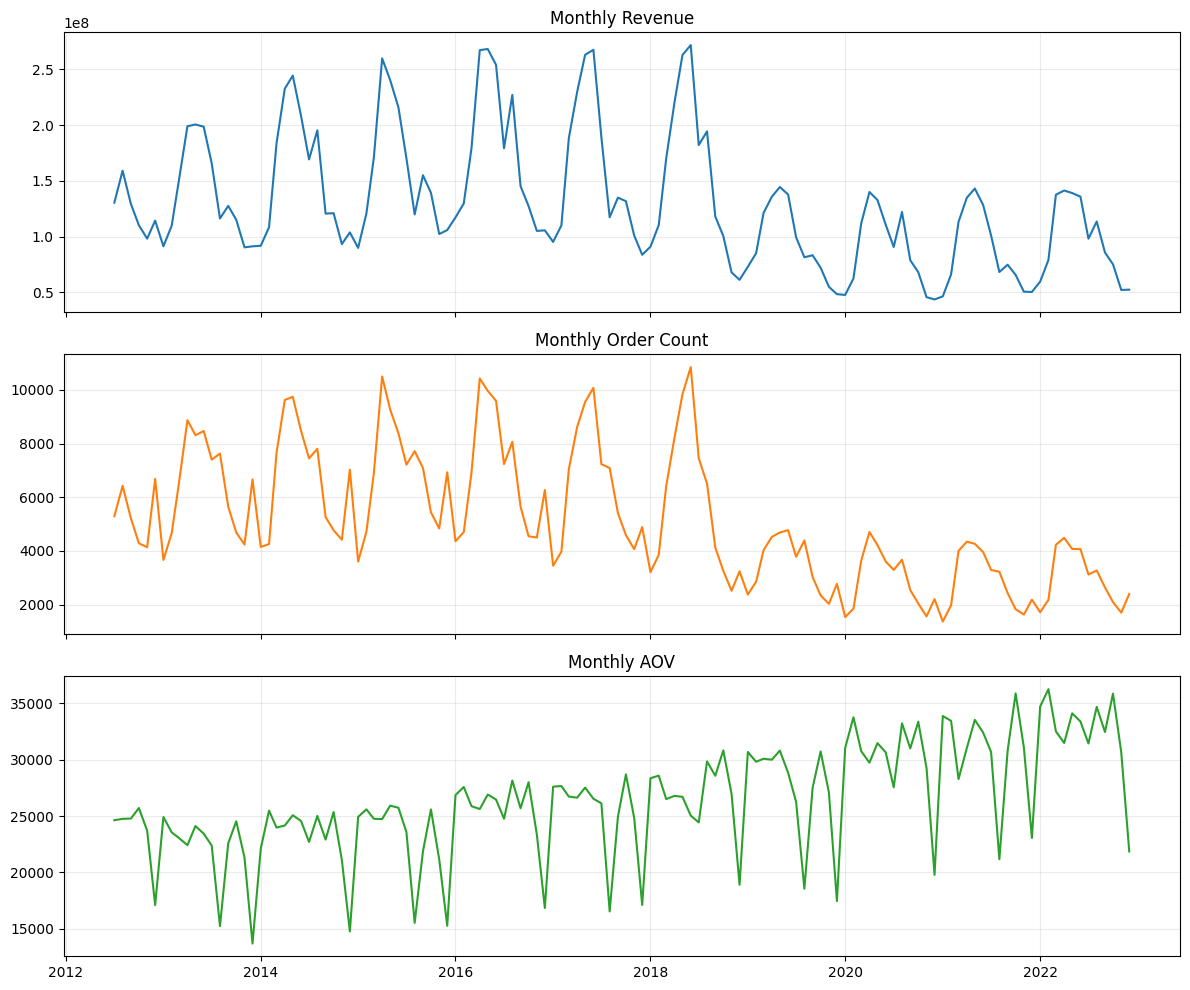

,year,Revenue,order_count,AOV
0,2012,"741,497,748.0200",32051,"23,134.9333"
1,2013,"1,657,169,417.2700",76849,"21,563.9685"
2,2014,"1,871,845,882.8000",80645,"23,210.9354"
3,2015,"1,889,933,826.9200",82622,"22,874.4623"
4,2016,"2,104,640,677.5400",82247,"25,589.2699"
5,2017,"1,911,164,325.2800",76010,"25,143.5906"
6,2018,"1,850,122,456.0800",69510,"26,616.6373"
7,2019,"1,136,801,441.5100",41601,"27,326.3008"
8,2020,"1,054,512,158.7900",34881,"30,231.7066"
9,2021,"1,043,039,819.6300",34525,"30,211.1461"


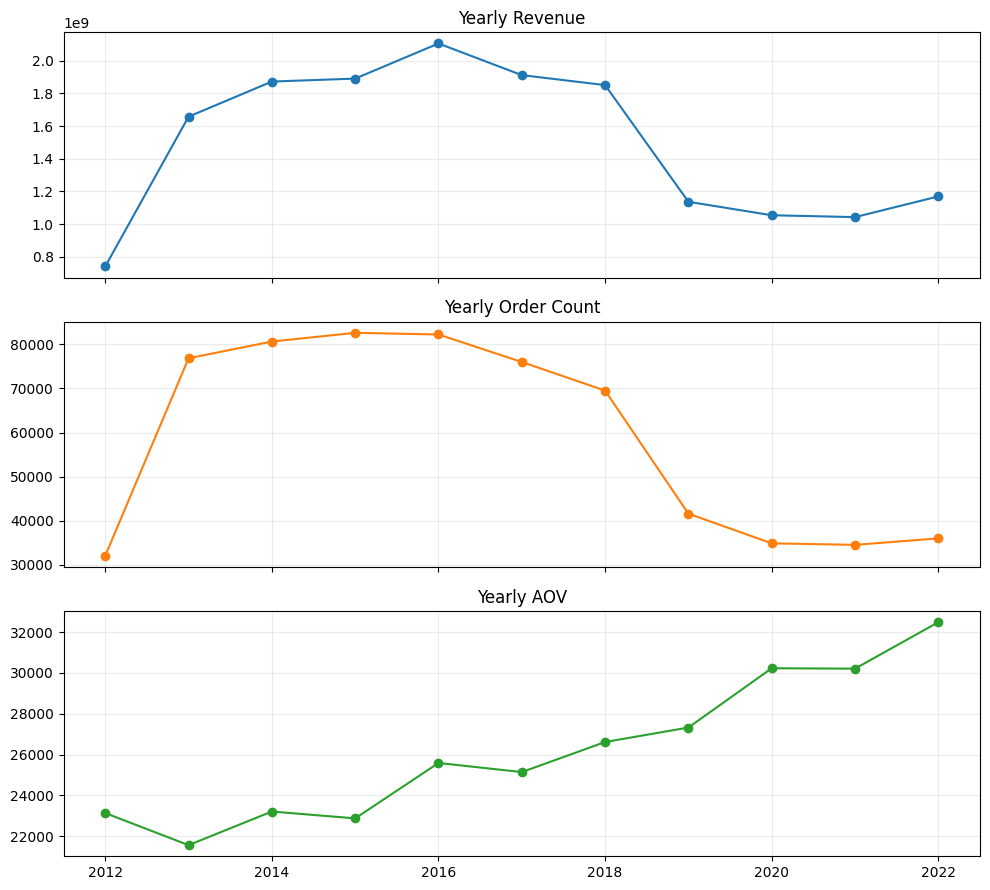

,year,Revenue,order_count,AOV,Revenue_yoy_change,order_count_yoy_change,AOV_yoy_change,yearly_growth_driver
0,2012,"741,497,748.0200",32051,"23,134.9333",NaN,NaN,NaN,AOV
1,2013,"1,657,169,417.2700",76849,"21,563.9685",1.2349,1.3977,-0.0679,order_count
2,2014,"1,871,845,882.8000",80645,"23,210.9354",0.1295,0.0494,0.0764,AOV
3,2015,"1,889,933,826.9200",82622,"22,874.4623",0.0097,0.0245,-0.0145,order_count
4,2016,"2,104,640,677.5400",82247,"25,589.2699",0.1136,-0.0045,0.1187,AOV
5,2017,"1,911,164,325.2800",76010,"25,143.5906",-0.0919,-0.0758,-0.0174,order_count
6,2018,"1,850,122,456.0800",69510,"26,616.6373",-0.0319,-0.0855,0.0586,order_count
7,2019,"1,136,801,441.5100",41601,"27,326.3008",-0.3856,-0.4015,0.0267,order_count
8,2020,"1,054,512,158.7900",34881,"30,231.7066",-0.0724,-0.1615,0.1063,order_count
9,2021,"1,043,039,819.6300",34525,"30,211.1461",-0.0109,-0.0102,-0.0007,order_count


In [13]:
yearly_decomp = pd.DataFrame()

if not monthly.empty:
    display(monthly.head(24))
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    axes[0].plot(monthly['month'], monthly['Revenue'], label='Revenue')
    axes[1].plot(monthly['month'], monthly['order_count'], label='Order count', color='tab:orange')
    axes[2].plot(monthly['month'], monthly['AOV'], label='AOV', color='tab:green')
    axes[0].set_title('Monthly Revenue')
    axes[1].set_title('Monthly Order Count')
    axes[2].set_title('Monthly AOV')
    plt.tight_layout()
    plt.show()

if not yearly.empty:
    display(yearly)
    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
    axes[0].plot(yearly['year'], yearly['Revenue'], marker='o')
    axes[1].plot(yearly['year'], yearly['order_count'], marker='o', color='tab:orange')
    axes[2].plot(yearly['year'], yearly['AOV'], marker='o', color='tab:green')
    axes[0].set_title('Yearly Revenue')
    axes[1].set_title('Yearly Order Count')
    axes[2].set_title('Yearly AOV')
    plt.tight_layout()
    plt.show()

    yearly_decomp = yearly.copy()
    yearly_decomp['Revenue_yoy_change'] = yearly_decomp['Revenue'].pct_change()
    yearly_decomp['order_count_yoy_change'] = yearly_decomp['order_count'].pct_change()
    yearly_decomp['AOV_yoy_change'] = yearly_decomp['AOV'].pct_change()
    yearly_decomp['yearly_growth_driver'] = np.where(
        yearly_decomp['order_count_yoy_change'].abs() > yearly_decomp['AOV_yoy_change'].abs(),
        'order_count',
        'AOV'
    )
    display(yearly_decomp)

## 14. Optional Validation Against sales.csv

Compare reconstructed daily Revenue with `sales.csv` daily Revenue when available. `sales.csv` remains validation-only here.

In [14]:
sales_validation = pd.DataFrame()

if sales is not None and sales_cols.get('date') and sales_cols.get('revenue') and not daily.empty:
    sales_clean = sales.copy()
    sales_clean['date_std'] = pd.to_datetime(sales_clean[sales_cols['date']], errors='coerce')
    sales_clean['sales_revenue_std'] = pd.to_numeric(sales_clean[sales_cols['revenue']], errors='coerce')
    sales_daily = sales_clean.groupby('date_std').agg(sales_revenue=('sales_revenue_std', 'sum')).reset_index().rename(columns={'date_std': 'date'})
    sales_validation = daily[['date', 'Revenue']].merge(sales_daily, on='date', how='inner')
    if not sales_validation.empty:
        sales_validation['difference'] = sales_validation['Revenue'] - sales_validation['sales_revenue']
        display(pd.DataFrame([{
            'overlapping_days': len(sales_validation),
            'correlation': sales_validation['Revenue'].corr(sales_validation['sales_revenue']),
            'total_difference': sales_validation['difference'].sum(),
            'mean_absolute_difference': sales_validation['difference'].abs().mean(),
        }]))
        display(sales_validation.head(10))

,overlapping_days,correlation,total_difference,mean_absolute_difference
0,3833,1.0000,0.0000,0.0000


,date,Revenue,sales_revenue,difference
0,2012-07-04,"5,123,547.9400","5,123,547.9400",0.0000
1,2012-07-05,"2,751,773.4500","2,751,773.4500",0.0000
2,2012-07-06,"3,054,029.4200","3,054,029.4200",0.0000
3,2012-07-07,"2,667,930.9400","2,667,930.9400",0.0000
4,2012-07-08,"2,360,851.9000","2,360,851.9000",0.0000
5,2012-07-09,"3,548,386.4600","3,548,386.4600",0.0000
6,2012-07-10,"5,234,938.6200","5,234,938.6200",0.0000
7,2012-07-11,"5,582,884.7800","5,582,884.7800",0.0000
8,2012-07-12,"5,734,632.0200","5,734,632.0200",0.0000
9,2012-07-13,"5,309,511.7100","5,309,511.7100",0.0000


## 15. Forecast Design: Component Model vs Hybrid Model

Two practical strategies are reasonable here:

1. Component model:
   - Forecast `order_count`
   - Forecast `AOV`
   - Combine them as `forecast_revenue = forecast_order_count * forecast_AOV`

2. Hybrid model:
   - Forecast `order_count` and `AOV`
   - Use those predicted components as features in a final Revenue model

Component modeling improves interpretability and often helps error analysis. A direct Revenue model can still capture residual effects. Any component predictions used as features must be out-of-fold during training or separately forecasted for the future period to avoid leakage.

## 16. Leakage-Safe Component Feature Preview

Build lagged and rolling component features only. Actual same-day or future order count and AOV must not be used directly.

In [15]:
feature_preview = pd.DataFrame()

if not daily.empty:
    feat = daily[['date', 'Revenue', 'order_count', 'AOV']].copy()
    for col, lags in [('order_count', [1, 7, 30]), ('AOV', [1, 7, 30]), ('Revenue', [1, 7])]:
        for lag in lags:
            feat[f'{col}_lag_{lag}'] = feat[col].shift(lag)

    feat['order_count_roll_mean_7'] = feat['order_count'].shift(1).rolling(7, min_periods=1).mean()
    feat['order_count_roll_mean_30'] = feat['order_count'].shift(1).rolling(30, min_periods=1).mean()
    feat['AOV_roll_mean_7'] = feat['AOV'].shift(1).rolling(7, min_periods=1).mean()
    feat['AOV_roll_mean_30'] = feat['AOV'].shift(1).rolling(30, min_periods=1).mean()
    feat['Revenue_roll_mean_30'] = feat['Revenue'].shift(1).rolling(30, min_periods=1).mean()
    feat['component_revenue_proxy_lag_1'] = feat['order_count_lag_1'] * feat['AOV_lag_1']
    feat['component_revenue_proxy_roll_30'] = feat['order_count_roll_mean_30'] * feat['AOV_roll_mean_30']

    preview_cols = [
        'date', 'Revenue', 'order_count', 'AOV',
        'order_count_lag_1', 'order_count_lag_7', 'order_count_lag_30',
        'order_count_roll_mean_7', 'order_count_roll_mean_30',
        'AOV_lag_1', 'AOV_lag_7', 'AOV_lag_30',
        'AOV_roll_mean_7', 'AOV_roll_mean_30',
        'Revenue_lag_1', 'Revenue_lag_7', 'Revenue_roll_mean_30',
        'component_revenue_proxy_lag_1', 'component_revenue_proxy_roll_30'
    ]
    feature_preview = feat[preview_cols].head(20)
    display(feature_preview)

print('All features shown above are historical-only. Actual future order count and actual future AOV must not be used directly unless they are separately forecasted or genuinely known before prediction.')

,date,Revenue,order_count,AOV,order_count_lag_1,order_count_lag_7,order_count_lag_30,order_count_roll_mean_7,order_count_roll_mean_30,AOV_lag_1,AOV_lag_7,AOV_lag_30,AOV_roll_mean_7,AOV_roll_mean_30,Revenue_lag_1,Revenue_lag_7,Revenue_roll_mean_30,component_revenue_proxy_lag_1,component_revenue_proxy_roll_30
0,2012-07-04,"5,123,547.9400",162,"31,626.8391",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.4500",97,"28,368.7985",162.0000,NaN,NaN,162.0000,162.0000,"31,626.8391",NaN,NaN,"31,626.8391","31,626.8391","5,123,547.9400",NaN,"5,123,547.9400","5,123,547.9400","5,123,547.9400"
2,2012-07-06,"3,054,029.4200",93,"32,839.0260",97.0000,NaN,NaN,129.5000,129.5000,"28,368.7985",NaN,NaN,"29,997.8188","29,997.8188","2,751,773.4500",NaN,"3,937,660.6950","2,751,773.4500","3,884,717.5339"
3,2012-07-07,"2,667,930.9400",73,"36,546.9992",93.0000,NaN,NaN,117.3333,117.3333,"32,839.0260",NaN,NaN,"30,944.8879","30,944.8879","3,054,029.4200",NaN,"3,643,116.9367","3,054,029.4200","3,630,866.8434"
4,2012-07-08,"2,360,851.9000",88,"26,827.8625",73.0000,NaN,NaN,106.2500,106.2500,"36,546.9992",NaN,NaN,"32,345.4157","32,345.4157","2,667,930.9400",NaN,"3,399,320.4375","2,667,930.9400","3,436,700.4178"
5,2012-07-09,"3,548,386.4600",137,"25,900.6311",88.0000,NaN,NaN,102.6000,102.6000,"26,827.8625",NaN,NaN,"31,241.9051","31,241.9051","2,360,851.9000",NaN,"3,191,626.7300","2,360,851.9000","3,205,419.4589"
6,2012-07-10,"5,234,938.6200",183,"28,606.2220",137.0000,NaN,NaN,108.3333,108.3333,"25,900.6311",NaN,NaN,"30,351.6927","30,351.6927","3,548,386.4600",NaN,"3,251,086.6850","3,548,386.4600","3,288,100.0458"
7,2012-07-11,"5,582,884.7800",221,"25,261.9221",183.0000,162.0000,NaN,119.0000,119.0000,"28,606.2220","31,626.8391",NaN,"30,102.3398","30,102.3398","5,234,938.6200","5,123,547.9400","3,534,494.1043","5,234,938.6200","3,582,178.4320"
8,2012-07-12,"5,734,632.0200",246,"23,311.5123",221.0000,97.0000,NaN,127.4286,131.7500,"25,261.9221","28,368.7985",NaN,"29,193.0659","29,497.2876","5,582,884.7800","2,751,773.4500","3,790,542.9388","5,582,884.7800","3,886,267.6352"
9,2012-07-13,"5,309,511.7100",201,"26,415.4811",246.0000,93.0000,NaN,148.7143,144.4444,"23,311.5123","32,839.0260",NaN,"28,470.5964","28,809.9792","5,734,632.0200","3,054,029.4200","4,006,552.8367","5,734,632.0200","4,161,441.4385"


All features shown above are historical-only. Actual future order count and actual future AOV must not be used directly unless they are separately forecasted or genuinely known before prediction.


## 17. Key Observations and Warnings

Summarize whether Revenue appears more order-count-driven or AOV-driven, how spike periods behave, and which component features look most useful.

In [16]:
summary_lines = ['KEY OBSERVATIONS AND WARNINGS']

if not driver_df.empty:
    overall = driver_df.loc[driver_df['period'] == 'overall']
    if not overall.empty:
        driver = overall['dominant_driver'].iloc[0]
        summary_lines.append(f'- Revenue movement appears more {driver}-driven overall.')

if not spike_df.empty:
    top_spikes = spike_df.sort_values('Revenue', ascending=False).head(5)
    spike_text = ', '.join(f"{r.date.date()} ({r.driver_classification})" for r in top_spikes.itertuples())
    summary_lines.append(f'- Strongest Revenue spike periods and likely drivers: {spike_text}.')

if not seasonal_table.empty:
    peak_months = seasonal_table.sort_values('Revenue_rank').head(3)
    peak_text = ', '.join(f"month {int(r.month_of_year)} ({r.peak_driver})" for r in peak_months.itertuples())
    summary_lines.append(f'- Peak seasons are mainly driven by: {peak_text}.')

if not yearly_decomp.empty:
    valid_year = yearly_decomp.dropna(subset=['Revenue_yoy_change'])
    if not valid_year.empty:
        dominant = valid_year['yearly_growth_driver'].value_counts().idxmax()
        summary_lines.append(f'- Yearly growth is more often driven by {dominant}.')

if not sales_validation.empty:
    corr = sales_validation['Revenue'].corr(sales_validation['sales_revenue'])
    total_diff = sales_validation['difference'].sum()
    summary_lines.append(f'- Reconstructed Revenue vs sales.csv validation: correlation {corr:.4f}, total difference {total_diff:,.2f}.')

if not driver_df.empty:
    overall = driver_df.loc[driver_df['period'] == 'overall']
    if not overall.empty:
        order_corr = abs(overall['revenue_vs_order_count'].iloc[0])
        aov_corr = abs(overall['revenue_vs_AOV'].iloc[0])
        if order_corr > aov_corr * 1.10:
            strategy = 'component model'
        elif aov_corr > order_corr * 1.10:
            strategy = 'hybrid model'
        else:
            strategy = 'hybrid model'
        summary_lines.append(f'- Recommended modeling strategy: {strategy}.')

if decomp_warnings:
    summary_lines.append('- Data quality warnings: ' + '; '.join(decomp_warnings))
else:
    summary_lines.append('- Data quality warnings: none beyond the checks reported in notebook tables.')

summary_lines.append('- Recommended leakage-safe component features: order_count_lag_1, order_count_lag_7, order_count_lag_30, order_count_roll_mean_7, order_count_roll_mean_30, AOV_lag_1, AOV_lag_7, AOV_lag_30, AOV_roll_mean_7, AOV_roll_mean_30, Revenue_lag_1, Revenue_lag_7, Revenue_roll_mean_30, component_revenue_proxy_lag_1, and component_revenue_proxy_roll_30.')
summary_lines.append('- Actual future order count and actual future AOV must not be used directly unless they are separately forecasted or genuinely known before prediction.')
summary_lines.append('- Causal caution: this is an arithmetic and descriptive decomposition, not causal proof. Revenue shifts can still reflect promotions, assortment, returns, pricing, and seasonality.')

print('\n'.join(summary_lines))

KEY OBSERVATIONS AND WARNINGS
- Revenue movement appears more order_count-driven overall.
- Strongest Revenue spike periods and likely drivers: 2018-05-30 (order_count_driven), 2018-05-31 (order_count_driven), 2018-06-01 (order_count_driven), 2017-06-01 (order_count_driven), 2018-06-02 (order_count_driven).
- Peak seasons are mainly driven by: month 5 (both), month 4 (high_order_volume), month 6 (high_order_volume).
- Yearly growth is more often driven by order_count.
- Reconstructed Revenue vs sales.csv validation: correlation 1.0000, total difference 0.00.
- Recommended modeling strategy: component model.
- Data quality warnings: none beyond the checks reported in notebook tables.
- Recommended leakage-safe component features: order_count_lag_1, order_count_lag_7, order_count_lag_30, order_count_roll_mean_7, order_count_roll_mean_30, AOV_lag_1, AOV_lag_7, AOV_lag_30, AOV_roll_mean_7, AOV_roll_mean_30, Revenue_lag_1, Revenue_lag_7, Revenue_roll_mean_30, component_revenue_proxy_lag_1, 